In [1]:
from dotenv import load_dotenv
from openai import OpenAI
import json
import os
import networkx as nx
from pathlib import Path

# Purpose: load saved MD&A text files for one company
# Input: ticker string
# Output: list of dictionaries with ticker, year, file path, and text
def load_mda_files(ticker):
    ticker = ticker.upper()
    folder = Path("..") / "data" / "raw" / ticker

    if not folder.exists():
        raise FileNotFoundError(f"Folder not found: {folder}")

    files = list(folder.glob("*.txt"))

    if not files:
        raise ValueError(f"No .txt files found in: {folder}")

    mda_records = []

    for file in files:
        with open(file, "r", encoding="utf-8") as f:
            text = f.read()

        year = file.stem.split("_")[1]

        mda_records.append({
            "ticker": ticker,
            "year": int(year),
            "file_path": str(file),
            "text": text
        })

    return mda_records

graph_schema = {
    "nodes": [
        {
            "id": "Revenue",
            "type": "financial_metric",
            "evidence": "short quote from MDA"
        }
    ],
    "edges": [
        {
            "source": "Revenue",
            "target": "Net Sales",
            "relationship": "is_component_of",
            "evidence": "short quote from MDA"
        }
    ]
}

ALLOWED_NODE_TYPES = [
    "financial_metric",
    "business_segment",
    "geography",
    "product",
    "risk_factor",
    "cost_driver",
    "growth_driver",
    "strategic_initiative",
    "macroeconomic_factor"
]

ALLOWED_RELATIONSHIPS = [
    "increases",
    "decreases",
    "drives",
    "constrains",
    "is_component_of",
    "impacts",
    "offsets",
    "depends_on",
    "compared_with"
]

In [2]:
records = load_mda_files("AMZN")

record = records[4]

print(record["ticker"], record["year"])
print(record["text"][:500])

AMZN 2026
Item 7.
Management’s Discussion and Analysis of Financial Condition and Results of Operations
Forward-Looking Statements
This Annual Report on Form 10-K includes forward-looking statements within the meaning of the Private Securities Litigation Reform Act of 1995. All statements other than statements of historical fact, including statements regarding guidance, industry prospects, or future results of operations or financial position, made in this Annual Report on Form 10-K are forward-looking. W


In [4]:
def build_graph_prompt(record):
    return f"""
You are extracting a knowledge graph from a company's MD&A section.

Company ticker: {record["ticker"]}
Filing year: {record["year"]}

Task:
Extract the major business and financial ideas from the MD&A as nodes, and extract the relationships between them as edges.

Allowed node types:
{ALLOWED_NODE_TYPES}

Allowed relationship types:
{ALLOWED_RELATIONSHIPS}

Return ONLY valid JSON with this structure:

{{
  "nodes": [
    {{
      "id": "Revenue",
      "type": "financial_metric",
      "evidence": "short quote from the MD&A"
    }}
  ],
  "edges": [
    {{
      "source": "Revenue",
      "target": "Profitability",
      "relationship": "drives",
      "evidence": "short quote from the MD&A"
    }}
  ]
}}

Rules:
- Use only information supported by the MD&A.
- Keep node ids short and readable.
- Do not invent relationships.
- Include 8 to 15 nodes.
- Include 8 to 20 edges.
- Evidence must be copied from the MD&A.
- Return JSON only.

MD&A text:
\"\"\"
{record["text"][:12000]}
\"\"\"
"""

In [5]:
prompt = build_graph_prompt(record)

print(prompt[:1000])
print(len(prompt))


You are extracting a knowledge graph from a company's MD&A section.

Company ticker: AMZN
Filing year: 2026

Task:
Extract the major business and financial ideas from the MD&A as nodes, and extract the relationships between them as edges.

Allowed node types:
['financial_metric', 'business_segment', 'geography', 'product', 'risk_factor', 'cost_driver', 'growth_driver', 'strategic_initiative', 'macroeconomic_factor']

Allowed relationship types:
['increases', 'decreases', 'drives', 'constrains', 'is_component_of', 'impacts', 'offsets', 'depends_on', 'compared_with']

Return ONLY valid JSON with this structure:

{
  "nodes": [
    {
      "id": "Revenue",
      "type": "financial_metric",
      "evidence": "short quote from the MD&A"
    }
  ],
  "edges": [
    {
      "source": "Revenue",
      "target": "Profitability",
      "relationship": "drives",
      "evidence": "short quote from the MD&A"
    }
  ]
}

Rules:
- Use only information supported by the MD&A.
- Keep node ids short a

In [6]:
load_dotenv()

client = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))

response = client.chat.completions.create(
    model="gpt-5-mini",
    messages=[
        {"role": "user", "content": prompt}
    ]
)

output_text = response.choices[0].message.content

print(output_text[:2000])

{
  "nodes": [
    {
      "id": "Revenue",
      "type": "financial_metric",
      "evidence": "Our primary source of revenue is the sale of a wide range of products and services to customers."
    },
    {
      "id": "ProductsAndServices",
      "type": "product",
      "evidence": "We also offer other services such as compute, storage, and database offerings, fulfillment, advertising, publishing, and digital content subscriptions."
    },
    {
      "id": "FreeCashFlow",
      "type": "financial_metric",
      "evidence": "Our financial focus is on long-term, sustainable growth in free cash flow."
    },
    {
      "id": "OperatingIncome",
      "type": "financial_metric",
      "evidence": "Increases in operating income primarily result from increases in sales of products and services and efficiently managing our operating costs"
    },
    {
      "id": "VariableCosts",
      "type": "cost_driver",
      "evidence": "Our variable costs include product and content costs, payment

In [7]:
graph_data = json.loads(output_text)

print(graph_data.keys())

print("Nodes:", len(graph_data["nodes"]))
print("Edges:", len(graph_data["edges"]))

graph_data["nodes"][0]
graph_data["edges"][0]

node_ids = {node["id"] for node in graph_data["nodes"]}

invalid_edges = [
    edge for edge in graph_data["edges"]
    if edge["source"] not in node_ids or edge["target"] not in node_ids
]

print("Invalid edges:", len(invalid_edges))

dict_keys(['nodes', 'edges'])
Nodes: 14
Edges: 16
Invalid edges: 0


In [8]:
G = nx.DiGraph()

for node in graph_data["nodes"]:
    G.add_node(
        node["id"],
        type=node["type"],
        evidence=node["evidence"]
    )

for edge in graph_data["edges"]:
    G.add_edge(
        edge["source"],
        edge["target"],
        relationship=edge["relationship"],
        evidence=edge["evidence"]
    )

print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())

Nodes: 14
Edges: 16


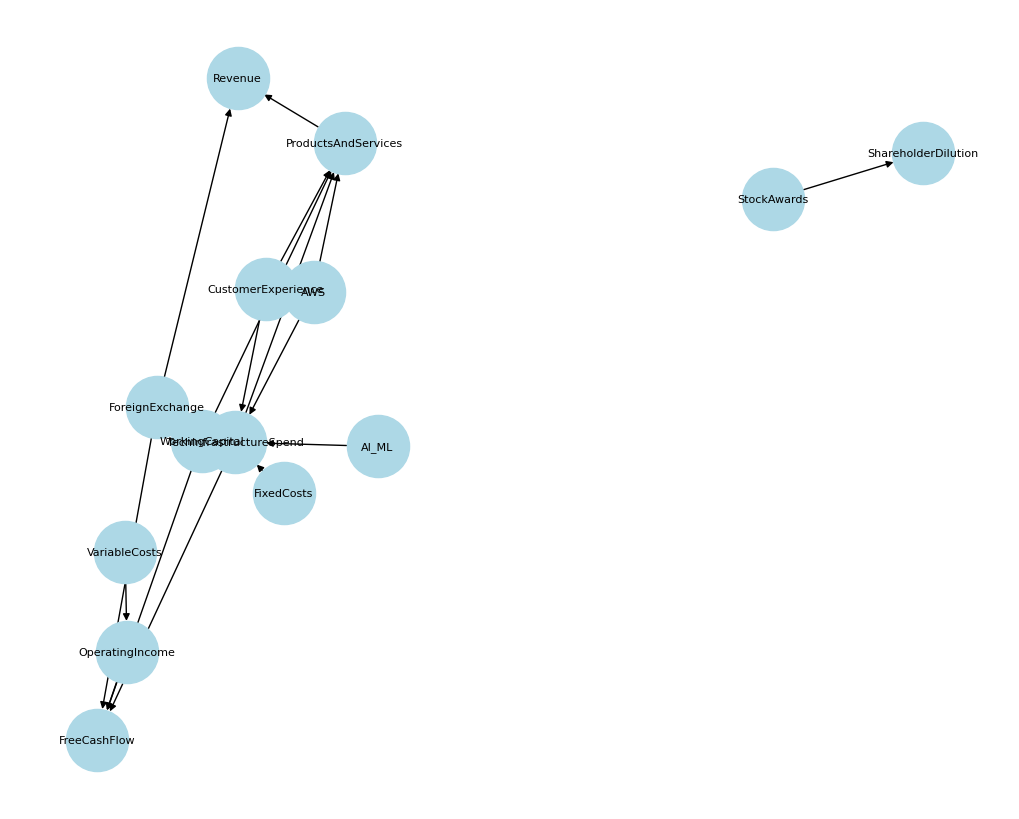

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

pos = nx.spring_layout(G, seed=42)

nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=2000,
    node_color="lightblue",
    font_size=8
)

plt.show()

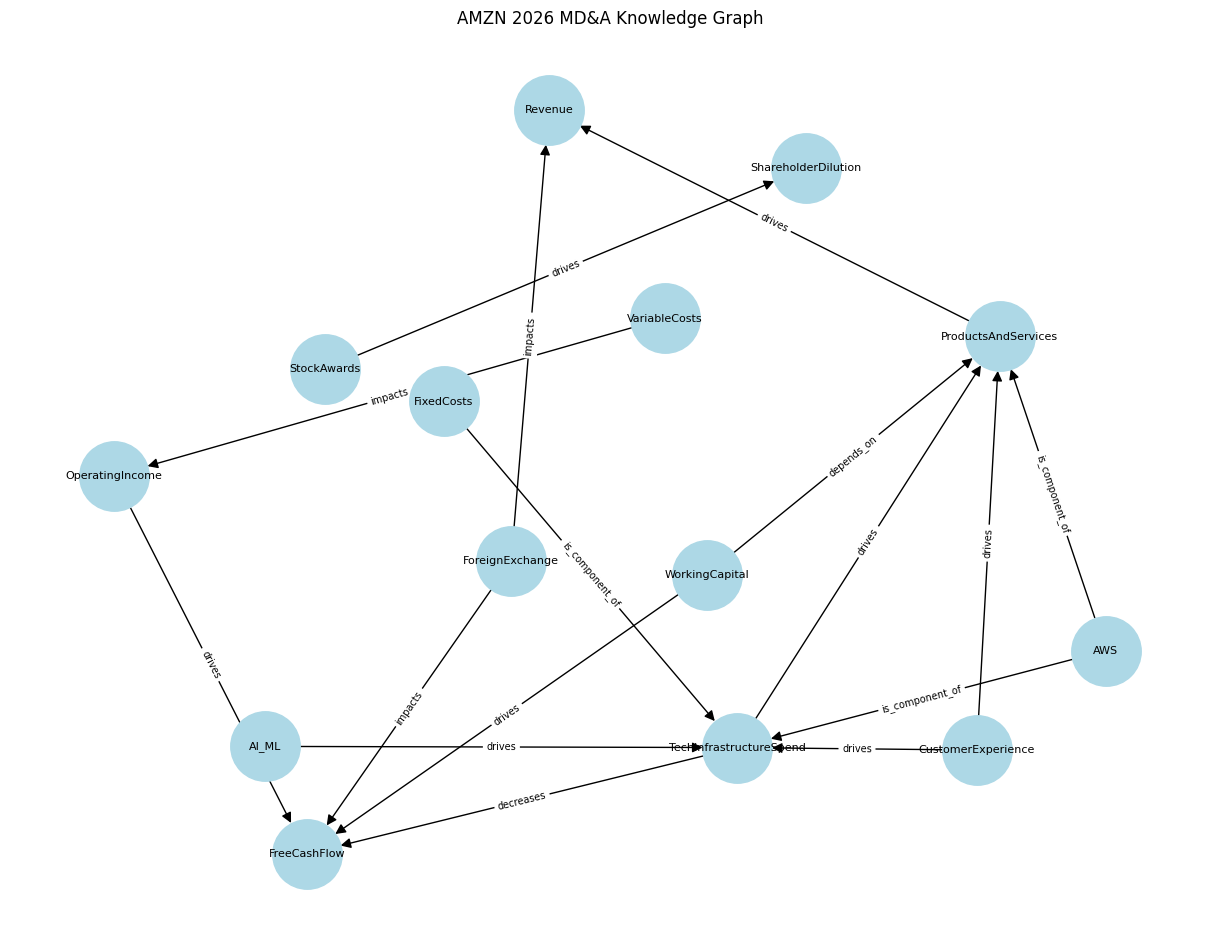

In [10]:
plt.figure(figsize=(12, 9))

pos = nx.spring_layout(G, seed=42, k=1.2)

nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=2500,
    node_color="lightblue",
    font_size=8,
    arrows=True,
    arrowsize=15
)

edge_labels = nx.get_edge_attributes(G, "relationship")

nx.draw_networkx_edge_labels(
    G,
    pos,
    edge_labels=edge_labels,
    font_size=7,
    label_pos=0.5
)

plt.title(f"{record['ticker']} {record['year']} MD&A Knowledge Graph")
plt.axis("off")
plt.show()